# Models training and tuning

We load the datasets prepared in notebook 2, define the feature set (shared by both models), and train Random Forest and XGBoost using the same methodology.

In [107]:
"""Import training and testing datasets"""
import pandas as pd
from pathlib import Path

TRAINING_PATH = Path("../data/training/tennis_training.xlsx")
TESTING_PATH = Path("../data/testing/tennis_testing.xlsx")

train_df = pd.read_excel(TRAINING_PATH)
test_df = pd.read_excel(TESTING_PATH)


In [ ]:
target = "y"

simple_features = [
     # "Rank_Diff", "Points_Diff",
    "Rank_Log_Ratio", "Points_Log_Ratio",
]

odds_features = [
    # "Odds_Diff",
    "Odds_Log_Ratio"
]

optimized_features = [
    "Elo_Diff", "Surface_Elo_Diff",
    "Age_Diff",
    "Recent_Form_Diff", "Recent_Surface_Form_Diff",
    "Fatigue_Diff", "Dominance_Form_Diff",
    "H2H_Diff", "H2H_Surface_Diff",
    "Hand_Advantage",
    "Home_Advantage",
]

categorical_features = ["Court", "Surface", "Round", "Tournament", "Series"]

features_no_odds = simple_features + optimized_features
features_with_odds = simple_features + odds_features + optimized_features

feature_sets = {
    "no_odds": features_no_odds,
    "with_odds": features_with_odds,
}

y_train = train_df[target]

### Why these features?

Incremental comparison using cross-validation, computed **only on the training set** (never on the test set), so this exploration does not leak into the final evaluation.

Note: this uses a small, fixed (non-tuned) Random Forest just to isolate the effect of each feature group. It runs in seconds because there is no hyperparameter search here (only 5 folds x 5 stages = 25 quick fits with shallow trees) — the real tuning happens further below with `RandomizedSearchCV`.

Base: 65.96% ± 1.74%
+ Elo: 67.31% ± 1.82%
+ Form/H2H (No odds): 68.17% ± 1.64%
+ Odds (All): 68.17% ± 1.64%


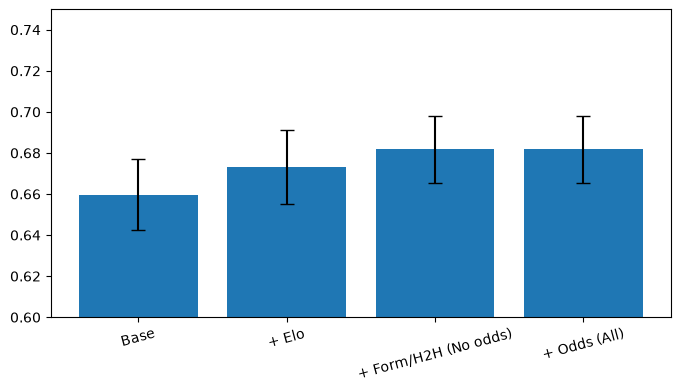

In [116]:
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

feature_stages = {
    "Base": ["Rank_Log_Ratio", "Points_Log_Ratio"],
    "+ Elo": ["Elo_Diff", "Surface_Elo_Diff"],
    "+ Form/H2H (No odds)": [f for f in features if f != "Odds_Diff"],
    "+ Odds (All)": features,
}

cv = TimeSeriesSplit(n_splits=5)
results = {}

for name, feats in feature_stages.items():
    model = make_pipeline(
        SimpleImputer(strategy="median", add_indicator=True),
        RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
    )
    scores = cross_val_score(model, train_df[feats], train_df["y"], cv=cv, scoring="accuracy")
    results[name] = (scores.mean(), scores.std())
    print(f"{name}: {scores.mean():.2%} ± {scores.std():.2%}")

# Plot
names, means, stds = results.keys(), [v[0] for v in results.values()], [v[1] for v in results.values()]
plt.figure(figsize=(8, 4))
plt.bar(names, means, yerr=stds, capsize=5)
plt.ylim(0.6, 0.75)
plt.xticks(rotation=15)
plt.show()

### Preprocessing pipeline

Same block for both models: median imputation for missing values (with a missing indicator). No scaling: neither Random Forest nor XGBoost need it.

In [110]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

def full_preprocessor(numerical_features, categorical_features):
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        # group rare or too frequent categories into "other"
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50, max_categories=20)),
    ])
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median", add_indicator=True), numerical_features),
        ("cat", categorical_pipeline, categorical_features),
    ])


### Random Forest

Random Forest does not require feature scaling or normalization.

In [111]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint

def train_rf(numerical_features, categorical_features, train_df, y_train):
    preprocessor = full_preprocessor(numerical_features, categorical_features)
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1)),
    ])
    param_distributions = {
        "model__n_estimators": randint(150, 400),
        "model__max_depth": randint(3, 10),
        "model__min_samples_leaf": randint(1, 20),
        "model__max_features": ["sqrt", "log2"],
        
        # Test different hyperparams for one hot encoder
        "preprocessor__cat__onehot__min_frequency": randint(20, 100),
        "preprocessor__cat__onehot__max_categories": randint(10, 40),
    }
    
    search = RandomizedSearchCV(
        pipeline, param_distributions, n_iter=50,
        scoring={"accuracy": "accuracy", "log_loss": "neg_log_loss"},
        cv=TimeSeriesSplit(n_splits=5), random_state=42, n_jobs=1, verbose=1, refit="accuracy",
    )
    
    X = train_df[numerical_features + categorical_features]
    search.fit(X, y_train)
    print("Best params:", search.best_params_)
    print("CV accuracy:", f"{search.best_score_:.2%}")
    return search

rf_models = {}
for label, feats in feature_sets.items():
    print(f"--- Random Forest ({label}) ---")
    rf_models[label] = train_rf(feats, categorical_features, train_df, y_train)


--- Random Forest (no_odds) ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'model__max_depth': 9, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 7, 'model__n_estimators': 201, 'preprocessor__cat__onehot__max_categories': 18, 'preprocessor__cat__onehot__min_frequency': 52}
CV accuracy: 68.22%
--- Random Forest (with_odds) ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'model__max_depth': 9, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 7, 'model__n_estimators': 201, 'preprocessor__cat__onehot__max_categories': 18, 'preprocessor__cat__onehot__min_frequency': 52}
CV accuracy: 69.89%


### XGBoost

Same feature set and same validation strategy (`TimeSeriesSplit`) as Random Forest, for a fair comparison.

In [115]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint, loguniform, uniform

def train_xgb(numerical_features, categorical_features, train_df, y_train):
    preprocessor = full_preprocessor(numerical_features, categorical_features)
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
        )),
    ])
    param_distributions = {
        "model__n_estimators": randint(150, 800),
        "model__learning_rate": loguniform(0.01, 0.2),
        "model__max_depth": randint(1, 5),
        "model__min_child_weight": loguniform(0.5, 10),
        "model__subsample": uniform(0.6, 0.4),
        "model__colsample_bytree": uniform(0.6, 0.4),
        "model__reg_alpha": loguniform(1e-4, 10),
        "model__reg_lambda": loguniform(0.1, 20),
        
        # Test different hyperparams for one hot encoder
        "preprocessor__cat__onehot__min_frequency": randint(20, 100),
        "preprocessor__cat__onehot__max_categories": randint(10, 40),
    }
    search = RandomizedSearchCV(
        pipeline, param_distributions, n_iter=50,
        scoring={"accuracy": "accuracy", "log_loss": "neg_log_loss"},
        cv=TimeSeriesSplit(n_splits=5), random_state=42, n_jobs=1, verbose=1, refit="accuracy",
    )
    X = train_df[numerical_features + categorical_features]
    search.fit(X, y_train)
    print("Best params:", search.best_params_)
    print("CV accuracy:", f"{search.best_score_:.2%}")
    return search

xgb_models = {}
for label, feats in feature_sets.items():
    print(f"--- XGBoost ({label}) ---")
    xgb_models[label] = train_xgb(feats, categorical_features, train_df, y_train)


--- XGBoost (no_odds) ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'model__colsample_bytree': np.float64(0.8767580790770773), 'model__learning_rate': np.float64(0.07050520093274679), 'model__max_depth': 1, 'model__min_child_weight': np.float64(0.8469427116611212), 'model__n_estimators': 729, 'model__reg_alpha': np.float64(0.0015354845024150162), 'model__reg_lambda': np.float64(0.5607308700117544), 'model__subsample': np.float64(0.8985965620472096), 'preprocessor__cat__onehot__max_categories': 17, 'preprocessor__cat__onehot__min_frequency': 26}
CV accuracy: 68.15%
--- XGBoost (with_odds) ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'model__colsample_bytree': np.float64(0.8446054843462723), 'model__learning_rate': np.float64(0.012768987921945092), 'model__max_depth': 3, 'model__min_child_weight': np.float64(2.246248225535263), 'model__n_estimators': 169, 'model__reg_alpha': np.float64(0.1777541111003925), 'model__reg_l

### Saving the models

In [113]:
import pickle
from pathlib import Path

Path("../models").mkdir(parents=True, exist_ok=True)
for label, search in {**{f"rf_{k}": v for k,v in rf_models.items()}, **{f"xgb_{k}": v for k,v in xgb_models.items()}}.items():
    with open(f"../models/{label}_model.pkl", "wb") as f:
        pickle.dump(search.best_estimator_, f)
    print(f"Saved {label}_model.pkl")


Saved rf_no_odds_model.pkl
Saved rf_with_odds_model.pkl
Saved xgb_no_odds_model.pkl
Saved xgb_with_odds_model.pkl
